<a href="https://colab.research.google.com/github/Hiero-o/cp_01_tritiack/blob/main/Desafio_Final_Energia_ONS_API_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [3]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [4]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [5]:
type(registros)

list

In [6]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

# DESAFIO 1 (Erick Banhos de Castro - RM 572131)

In [7]:
### Identificação dos atributos - Data/hora: `dat_referencia` - Área de carga: `cod_areacarga` - Valor de carga: `val_cargaglobal`

#1.
dados = pd.DataFrame(registros)
#2.
dados.head()
#3.
print("Quantidade de linhas:", dados.shape[0])
print("Quantidade de colunas:", dados.shape[1])
#4.
dados.columns.tolist()
#5.
dados.info()
#6.
dados.describe()

Quantidade de linhas: 336
Quantidade de colunas: 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [8]:
df1 = dados.rename(columns={'din_referenciautc': 'data/hora',
                      'cod_areacarga': 'area_de_carga',
                      'val_cargaglobal': 'valor_de_carga'
                    }, inplace=True)

df1 = dados[['data/hora', 'area_de_carga', 'valor_de_carga']]


print(df1.isna().sum())

print(df1['valor_de_carga'].dtype)

print(df1['data/hora'].dtype)

df1.head()



data/hora         0
area_de_carga     0
valor_de_carga    0
dtype: int64
float64
object


,data/hora,area_de_carga,valor_de_carga
0,2025-08-01T03:30:00.000Z,SP,15913.618
1,2025-08-01T04:00:00.000Z,SP,15251.414
2,2025-08-01T04:30:00.000Z,SP,14606.733
3,2025-08-01T05:00:00.000Z,SP,14182.290
4,2025-08-01T05:30:00.000Z,SP,13838.488


### Desafio 2 — decisões de tratamento (Victor Henrique - 570021)

- Renomeei as colunas pra nomes mais simples: `data/hora`, `area_de_carga`, `valor_de_carga`.
- Fiquei só com essas 3 colunas, o resto não interessa pra essa análise.
- Sem valores ausentes (conferido com `isna().sum()`).
- `valor_de_carga` já vem numérico (`float64`), não precisou converter.
- `data/hora` vem como string (formato tipo `2025-08-01T03:30:00.000Z`), tipo `object`. Não converti agora, mas vou precisar usar `pd.to_datetime()` depois pra mexer com datas de verdade.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [9]:
menor_carga = df1['valor_de_carga'].min()

print(menor_carga)

maior_carga = df1['valor_de_carga'].max()

print(maior_carga)

media_carga = df1['valor_de_carga'].mean()

print(media_carga)

mediana_carga = df1['valor_de_carga'].median()

print(mediana_carga)

amplitude_carga = maior_carga - menor_carga

print(amplitude_carga)

quantidade_registros = len(df1)

print(quantidade_registros)

12139.253
23185.312
17870.828980654762
18199.1285
11046.059000000001
336


### Desafio 3 — indicadores da carga elétrica (Gustavo RM 574156)

- Carga mínima: `12139.253`
- Carga máxima: `23185.312`
- Carga média: `17870.83`
- Mediana: `18199.13`
- Amplitude (máx - mín): `11046.06`
- Total de medições: `336`

**O valor máximo está muito distante do comportamento médio?**

Não muito. A média (17870.83) e a mediana (18199.13) tão bem próximas uma da outra, o que já mostra que os dados não têm uma distorção forte. O máximo (23185.312) fica uns 5300 acima da média, o que é quase metade da amplitude total (11046.06) — ou seja, é um valor alto, mas dentro da faixa de variação normal da série, não parece um pico isolado ou outlier.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [10]:
carga_maxima = df1['valor_de_carga'].max()

limiar = carga_maxima * 0.90

print("Carga máxima:", carga_maxima)
print("Limiar de alta demanda (90%):", limiar)

df_alta_demanda = df1[df1['valor_de_carga'] > limiar].copy()

print("\nRegistros de alta demanda:")
display(df_alta_demanda)

quantidade_alta_demanda = len(df_alta_demanda)

print("\nQuantidade de registros acima do limiar:",
      quantidade_alta_demanda)

total_registros = len(df1)

percentual_alta_demanda = (
    quantidade_alta_demanda / total_registros
) * 100

print("Percentual de registros de alta demanda:",
      percentual_alta_demanda, "%")

maior_carga = df1['valor_de_carga'].max()

print("\nMaior valor de carga:",
      maior_carga)

indice_pico = df1['valor_de_carga'].idxmax()

data_pico = df1.loc[indice_pico, 'data/hora']
area_pico = df1.loc[indice_pico, 'area_de_carga']

print("Data e horário do pico:",
      data_pico)

print("Área de carga no pico:",
      area_pico)

Carga máxima: 23185.312
Limiar de alta demanda (90%): 20866.7808

Registros de alta demanda:


,data/hora,area_de_carga,valor_de_carga
35,2025-08-01T21:00:00.000Z,SP,21088.959
36,2025-08-01T21:30:00.000Z,SP,22398.360
37,2025-08-01T22:00:00.000Z,SP,23185.312
38,2025-08-01T22:30:00.000Z,SP,22903.314
39,2025-08-01T23:00:00.000Z,SP,22358.701
40,2025-08-01T23:30:00.000Z,SP,21697.979
41,2025-08-02T00:00:00.000Z,SP,21385.326
42,2025-08-02T00:30:00.000Z,SP,20919.314
84,2025-08-02T21:30:00.000Z,SP,20983.484
85,2025-08-02T22:00:00.000Z,SP,21202.566



Quantidade de registros acima do limiar: 50
Percentual de registros de alta demanda: 14.880952380952381 %

Maior valor de carga: 23185.312
Data e horário do pico: 2025-08-01T22:00:00.000Z
Área de carga no pico: SP


# DESAFIO 4 (CARLOS RM 573334)

Calcular o limiar: 20866.78w

Crie um novo DataFrame com os registros acima dele.

Conte os registros: 50 (alta demanda) 336 (Total)

Calcule o percentual em relação ao total: 14.88%

Identifique o maior valor de carga: 23185.312

Identifique a data e o horário do pico, quando disponíveis:

01/08/2025 às 22:00 UTC

Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?

Os períodos próximos ao pico representam uma parcela pequena do período analisado. Como a alta demanda foi definida como cargas acima de (90%) do valor máximo, apenas uma parte dos registros se enquadra nesse critério. Ou seja, os valores próximos ao pico aparecem em poucos momentos da série, enquanto a maior parte do período apresenta cargas abaixo desse nível.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

## Desafio 5 — Erick Yu Xiang(RM569305)

O critério escolhido foi considerar os registros com **carga acima da média**.

A média da carga no período analisado foi de aproximadamente **17870,83**. Foi criado um novo DataFrame contendo somente os registros com `valor_de_carga` superior a esse valor.

Após o filtro, foi calculada a quantidade de registros e o percentual que eles representam em relação às 336 medições totais.

Comparando esse conjunto com o de **alta demanda**, que considera apenas valores superiores a 90% da carga máxima, o critério de carga acima da média é menos restritivo. Por isso, ele tende a selecionar uma quantidade maior de registros.

O recorte de alta demanda representa situações mais próximas do pico de consumo, enquanto o recorte acima da média permite observar de forma mais ampla os períodos em que a carga esteve acima do comportamento médio observado.


In [11]:
media_carga = df1['valor_de_carga'].mean()

df_acima_media = df1[
    df1['valor_de_carga'] > media_carga
].copy()

quantidade_acima_media = len(df_acima_media)

percentual_acima_media = (
    quantidade_acima_media / len(df1)
) * 100


quantidade_alta_demanda = len(df_alta_demanda)

percentual_alta_demanda = (
    quantidade_alta_demanda / len(df1)
) * 100

print("Média da carga:", media_carga)

print("\nRegistros com carga acima da média:")
display(df_acima_media)

print("\nQuantidade de registros:", quantidade_acima_media)
print("Percentual:", percentual_acima_media, "%")

print("\nComparação com a alta demanda:")
print("Acima da média:", quantidade_acima_media,
      "registros -", percentual_acima_media, "%")

print("Alta demanda (> 90% do máximo):",
      quantidade_alta_demanda,
      "registros -", percentual_alta_demanda, "%")

Média da carga: 17870.828980654762

Registros com carga acima da média:


,data/hora,area_de_carga,valor_de_carga
15,2025-08-01T11:00:00.000Z,SP,18096.023
16,2025-08-01T11:30:00.000Z,SP,18629.395
17,2025-08-01T12:00:00.000Z,SP,18825.176
18,2025-08-01T12:30:00.000Z,SP,19056.504
19,2025-08-01T13:00:00.000Z,SP,19427.822
...,...,...,...
330,2025-08-08T00:30:00.000Z,SP,21716.170
331,2025-08-08T01:00:00.000Z,SP,20930.443
332,2025-08-08T01:30:00.000Z,SP,19936.190
333,2025-08-08T02:00:00.000Z,SP,19153.877



Quantidade de registros: 184
Percentual: 54.761904761904766 %

Comparação com a alta demanda:
Acima da média: 184 registros - 54.761904761904766 %
Alta demanda (> 90% do máximo): 50 registros - 14.880952380952381 %


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

## DESAFIO 6 - Júlia Lemos Souza (RM569089)

### Gráfico 1 — Comportamento da carga ao longo do tempo

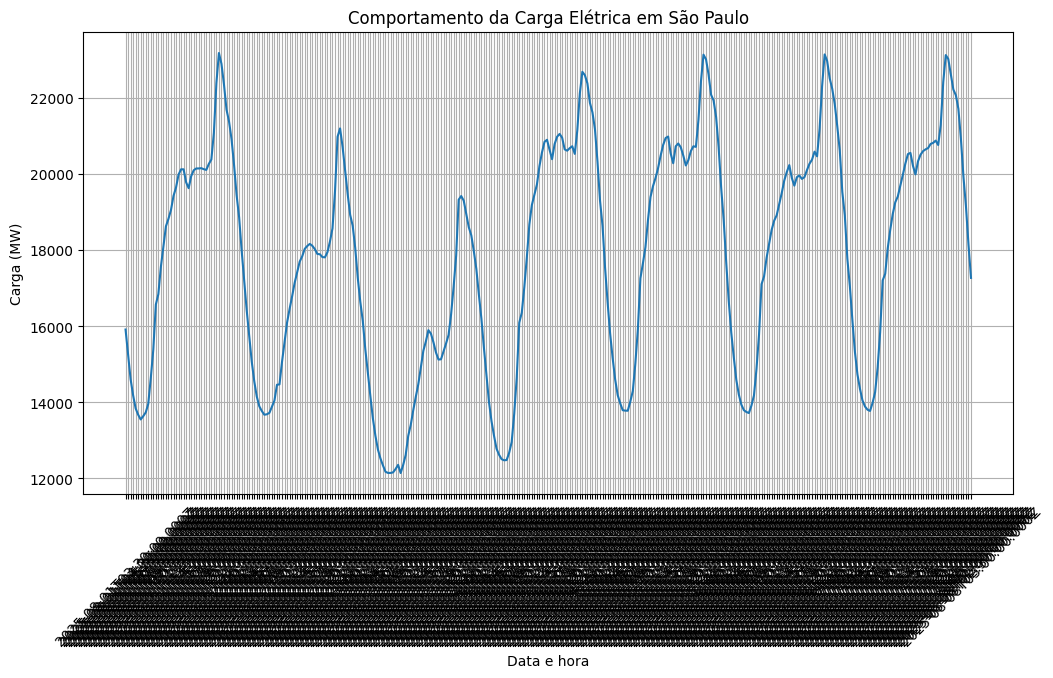

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df1['data/hora'],
         df1['valor_de_carga'],
         linewidth=1.5
)

plt.title('Comportamento da Carga Elétrica em São Paulo')
plt.xlabel('Data e hora')
plt.ylabel('Carga (MW)')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

O gráfico mostra como a carga elétrica variou ao longo do período analisado. É possível observar que a carga não permanece constante, apresentando momentos de aumento e redução. Os maiores valores aparecem principalmente nos períodos de maior demanda, enquanto em outros horários a carga apresenta valores menores.

### Gráfico 2 - Comparação entre carga máxima e carga média

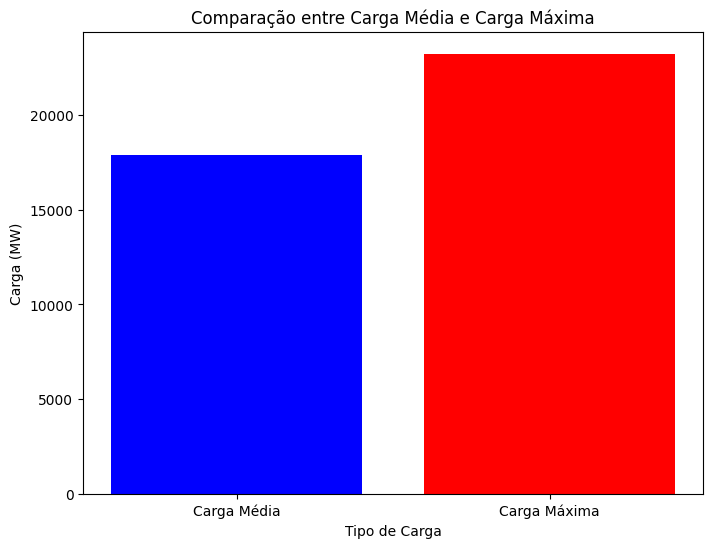

In [13]:
carga_maxima = df1['valor_de_carga'].max()
carga_media = df1['valor_de_carga'].mean()

valores = [carga_media, carga_maxima]
nomes = ['Carga Média', 'Carga Máxima']

plt.figure(figsize=(8, 6))
plt.bar(nomes, valores, color=['blue', 'red'])

plt.title('Comparação entre Carga Média e Carga Máxima')
plt.xlabel('Tipo de Carga')
plt.ylabel('Carga (MW)')

plt.show()

O segundo gráfico compara a carga média registrada durante o período com a maior carga registrada. A carga máxima é maior que a média, mostrando que existiram momentos de demanda elevada durante o período analisado. Essa comparação ajuda a visualizar a diferença entre o comportamento médio da carga e o momento de maior demanda.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [14]:
# Exemplo de estrutura:
#
# resumo_resultados = f'''
# Região analisada: ...
# Período analisado: ...
# Quantidade de registros: ...
# Carga mínima: ...
# Carga máxima: ...
# Carga média: ...
# Mediana: ...
# Limiar de alta demanda: ...
# Registros de alta demanda: ...
# Percentual de alta demanda: ...
# Momento do pico: ...
# Segundo critério: ...
# '''
#
# print(resumo_resultados)

# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [15]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 11.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [16]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

SecretNotFoundError: Secret GEMINI_API_KEY does not exist.

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

_Escreva aqui a versão final revisada._

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**

In [ ]:
awdadawdawdawda